In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import sys 
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from functions.funcs import *
import geopandas as gpd
import matplotlib.gridspec as gridspec
import seaborn as sns
import shapely as shp

## Analyizing Forcasts for: CMEMS, Kriging, and percistance

In [2]:
ds = pd.read_csv("saved_output/combined_krigging2024.csv")
ds2 = pd.read_csv("./saved_output/combined_cmems2024.csv")
ds3 = pd.read_csv("saved_output/combined_Percistance2024.csv")
#pts = pd.read_csv("../Data/pts_csv.csv")
ds3 = ds3.drop(columns= "BouyID")
ds3=ds3.rename(columns={"Latitude_true" : "lat_true", "Longitude_true": "lon_true", 
                  "Latitude_persistence": "lat_forcast",
                    "Longitude_persistence": "lon_forcast", 
                    "lead_time_hours": "leadtime" , "DateTime": "Time"})



In [3]:
def haversine_df(df, lat1='lat1', lon1='lon1', lat2='lat2', lon2='lon2', radius=6371):
    """
    Compute the Haversine distance between two points for every row of a DataFrame.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing latitude/longitude columns
    lat1, lon1 : str
        Names of the first point's latitude/longitude columns
    lat2, lon2 : str
        Names of the second point's latitude/longitude columns
    radius : float
        Earth radius in meters (default is 6371000 m)

    Returns
    -------
    pandas.Series
        Distance (meters) for each row.
    """

    # Convert degrees → radians
    lat1_r = np.radians(df[lat1].values)
    lon1_r = np.radians(df[lon1].values)
    lat2_r = np.radians(df[lat2].values)
    lon2_r = np.radians(df[lon2].values)

    # Differences
    dlat = lat2_r - lat1_r
    dlon = lon2_r - lon1_r

    # Haversine formula
    a = np.sin(dlat / 2)**2 + np.cos(lat1_r) * np.cos(lat2_r) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return radius * c


In [4]:
ds['error_lat'] = (ds["lat_true"] - ds["lat_forcast"]).abs()
ds['error_lon'] = (ds['lon_true'] -ds['lon_forcast']).abs()
ds['error_km'] = haversine_df(ds, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
ds2['error_km'] = haversine_df(ds2, "lat_true", "lon_true", "lat_forcast", "lon_forcast")
ds3["error_km"] = haversine_df(ds3,  "lat_true", "lon_true", "lat_forcast", "lon_forcast")

In [5]:
def calculate_rmse(group):
    rmse = np.sqrt((group["error_km"]**2).mean())
    return rmse 

In [6]:
bins = np.linspace(0,8*24,2*24+1)
ds2["lead_bins"] = pd.cut(ds2["leadtime"], bins)
ds ["lead_bins"] = pd.cut(ds["leadtime"], bins)
ds3["lead_bins"] = pd.cut(ds3["leadtime"], bins)
lte = ds.groupby("lead_bins", observed=False).apply(calculate_rmse, include_groups=False).to_numpy()
lte2  = ds2.groupby("lead_bins", observed=False).apply(calculate_rmse, include_groups=False).to_numpy()
lte3 = ds3.groupby("lead_bins", observed= False).apply(calculate_rmse, include_groups=False).to_numpy()
std = ds.groupby("lead_bins", observed=False)["error_km"].std()
std2 = ds2.groupby("lead_bins", observed=False)["error_km"].std()
std3 = ds3.groupby("lead_bins", observed= False)["error_km"].std()


pad = np.array([0])
lte  = np.concat([pad,lte])
pad = np.array([0])
lte2 = np.concat([pad,lte2])
lte3 = np.concat([pad,lte3])
std = np.concat([pad,std])
std2 = np.concat([pad, std2])
std3 = np.concat([pad,std3])

kriging_km24 = (lte2[:7]- lte[:7]).mean()
krigging_percent24 = np.abs((lte[:7].mean()- lte2[:7].mean())/lte2[:7].mean()*100)
Pers_km24 = (lte2[:7]- lte3[:7]).mean()
Pers_percent24 = np.abs((lte3[:7].mean()- lte2[:7].mean())/lte2[:7].mean()*100)
print(f"percent of Krigging improvent 24hr :{krigging_percent24} ")
print(f"Kriging improvement km : {kriging_km24}")


percent of Krigging improvent 24hr :17.378735594713802 
Kriging improvement km : 1.9443579393359909


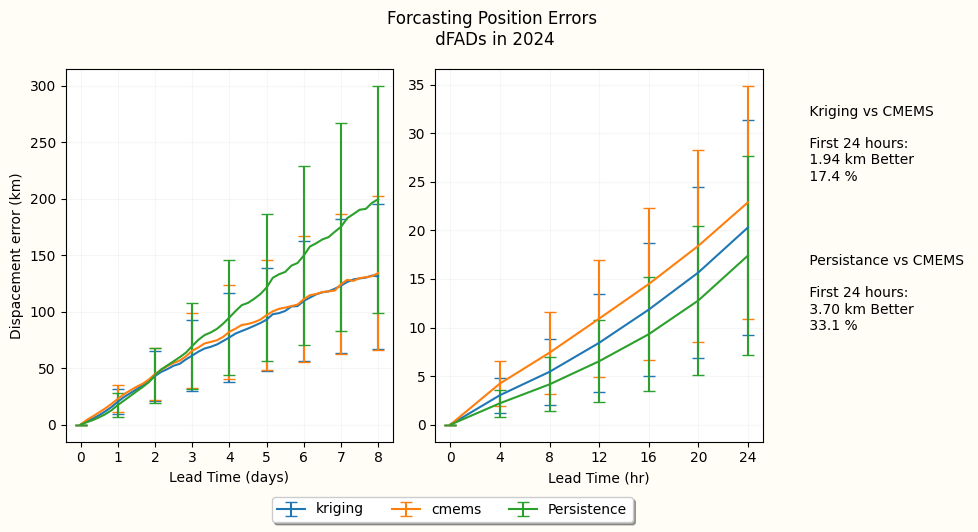

In [7]:
fig = plt.figure(figsize=(10,5))
gs = gridspec.GridSpec(1, 3, width_ratios=[3,3,1])

ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1])
ax_stats = fig.add_subplot(gs[0,2])
ax_stats.axis("off")

stats_k = f" Kriging vs CMEMS \n \n First 24 hours: \n {kriging_km24:0.2f} km Better \n{krigging_percent24: 0.1f} %"
ax_stats.text(0,0.7,stats_k)

stats_p = f" Persistance vs CMEMS \n \n First 24 hours: \n {Pers_km24:0.2f} km Better \n{Pers_percent24: 0.1f} %"
ax_stats.text(0,0.3,stats_p)

ax0.errorbar(bins[:]/24, lte[:], yerr = std, errorevery=6, capsize = 4, label = "kriging")
ax0.errorbar(bins[:]/24, lte2[:], yerr = std2[:], errorevery=6, capsize = 4, label = "cmems")
ax0.errorbar(bins[:]/24, lte3[:], yerr = std3[:], errorevery = 6, capsize = 4, label = "Persistence")


ax1.errorbar(bins[0:7], lte[:7], yerr = std[:7], capsize = 4)
ax1.errorbar(bins[0:7], lte2[:7], yerr = std2[:7], capsize = 4)
ax1.errorbar(bins[0:7], lte3[:7], yerr = std3[:7], capsize =4 )
ax0.set_xticks(np.linspace(0,8,9))
ax1.set_xticks(np.linspace(0,24,7))

ax0.set_ylabel("Dispacement error (km)")
ax0.set_xlabel("Lead Time (days)")
ax1.set_xlabel("Lead Time (hr)")
ax0.grid(alpha = 0.1)
ax1.grid(alpha = 0.1)


fig.legend(loc='upper center', bbox_to_anchor=(3.2/7, 0.02),
          fancybox=True, shadow=True, ncol=5)
fig.suptitle("Forcasting Position Errors \n dFADs in 2024 ")
fig.set_facecolor("#FFFDF6")
fig.tight_layout()
fig.savefig(r"C:\FATE\Figures\Leadtime_cmems_krigging_persistance.png")

In [8]:
## Check covarience/corrilation between cmems and kirigging. 
corrilation = np.corrcoef(ds["error_km"].dropna(), ds2["error_km"].dropna() )
print(f"Corrilation between cmems and krigging errors: {corrilation[1,0]: 0.4f}")

Corrilation between cmems and krigging errors:  0.6315


### within one degree of Palmyra

In [9]:
##filter for errors within 1 degree of palymra
import shapely 
palmyra = Palmyra_obj()

deg = 1
ds_1d = ds[ds["lat_true"] < palmyra.y+deg]
ds_1d = ds_1d[ds_1d["lat_true"] > palmyra.y-deg]
ds_1d = ds_1d[ds_1d["lon_true"] < palmyra.x +deg]
ds_1d = ds_1d[ds_1d["lon_true"] > palmyra.x - deg]
ds2_1d = ds2[ds2["lat_true"] < palmyra.y+deg]
ds2_1d = ds2_1d[ds2_1d["lat_true"] > palmyra.y-deg]
ds2_1d = ds2_1d[ds2_1d["lon_true"] < palmyra.x +deg]
ds2_1d = ds2_1d[ds2_1d["lon_true"] > palmyra.x - deg]

lte_1d = ds_1d.groupby("lead_bins", observed=False).apply(calculate_rmse, include_groups=False).to_numpy()
lte2_1d  = ds2_1d.groupby("lead_bins", observed=False).apply(calculate_rmse, include_groups=False).to_numpy()
std_1d = ds_1d.groupby("lead_bins", observed=False)["error_km"].std()
std2_1d = ds2_1d.groupby("lead_bins", observed=False)["error_km"].std()

pad = np.array([0])
lte_1d  = np.concat([pad,lte_1d])
pad = np.array([0])
lte2_1d = np.concat([pad,lte2_1d])
std_1d = np.concat([pad,std_1d])
std2_1d = np.concat([pad, std2_1d])

Text(0.5, 0.98, 'Position Errors within 1 degree of Palmyra')

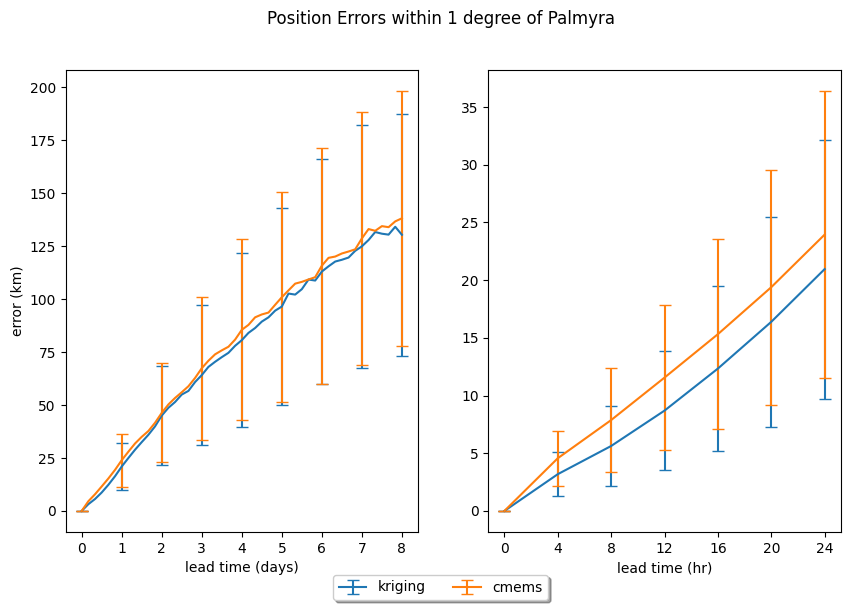

In [10]:
fig, ax = plt.subplots(1,2, figsize = (10,6))
ax[0].errorbar(bins[:]/24, lte_1d[:], yerr = std_1d, errorevery=6, capsize = 4, label = "kriging")
ax[0].errorbar(bins[:]/24, lte2_1d[:], yerr = std2_1d[:], errorevery=6, capsize = 4, label = "cmems")

ax[1].errorbar(bins[0:7], lte_1d[:7], yerr = std_1d[:7], capsize = 4)
ax[1].errorbar(bins[0:7], lte2_1d[:7], yerr = std2_1d[:7], capsize = 4)
ax[0].set_xticks(np.linspace(0,8,9))
ax[1].set_xticks(np.linspace(0,24,7))

ax[0].set_ylabel("error (km)")
ax[0].set_xlabel("lead time (days)")
ax[1].set_xlabel("lead time (hr)")


fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.05),
          fancybox=True, shadow=True, ncol=5)
fig.suptitle("Position Errors within 1 degree of Palmyra")

### Combining Drifter and dFAD data. 



C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_17424\1483259752.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  std_f=pts.groupby('lead_bin')['error_forecast_km'].std()
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_17424\1483259752.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  std_p=pts.groupby('lead_bin')['error_persistence_km'].std()
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_17424\1483259752.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to ado

(49,)
43


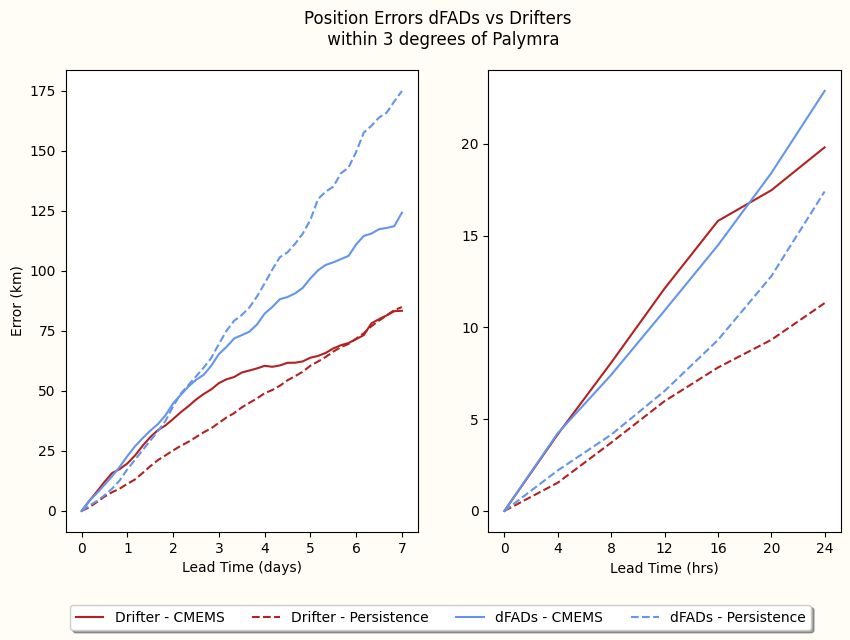

In [11]:
from functools import partial
pts = pd.read_csv("../Data/pts_new 1.csv", low_memory=False)

pts['DateTime']=pd.to_datetime(pts['DateTime'], format='mixed')
pts['issuance_dt']=pd.to_datetime(pts['issuance_dt'], format='mixed')
 
 
# Compute lead time in case it is missing
if 'lead_time_hours_from_issuance' not in pts.columns:
    pts['lead_time_hours_from_issuance']=(
        pts['DateTime']-pts['issuance_dt']
    ).dt.total_seconds()/3600
 
# Lead time bins (0-168 hrs which is 7 days)
lead_time_bins=np.linspace(0,7*24,6*7+1)
pts['lead_bin']=pd.cut(
    pts['lead_time_hours_from_issuance'],
    bins=lead_time_bins
)
 
 
pts['error_forecast_km']=pts['error_forecast_m']/1000
pts['error_persistence_km']=pts['error_persistence_m']/1000
 
def calculate_rmse(group, model):
    rmse = np.sqrt((group[f"error_{model}_km"]**2).mean())
    return rmse
 
# Restrict to box around Palmyra
lon_mask= (pts['Longitude_true'] > 196.17) & (pts['Longitude_true'] < 199.584)
lat_mask=(pts['Latitude_true'] > 4.4166) & (pts['Latitude_true'] < 7.83)
pts=pts[lon_mask & lat_mask]
 
std_f=pts.groupby('lead_bin')['error_forecast_km'].std()
std_p=pts.groupby('lead_bin')['error_persistence_km'].std()
rmse_f=pts.groupby('lead_bin').apply(
    partial(calculate_rmse, model='forecast'),
    include_groups=False
).to_numpy()
rmse_p=pts.groupby('lead_bin').apply(
    partial(calculate_rmse, model='persistence'),
    include_groups=False
).to_numpy()
lte_f=rmse_f
lte_p=rmse_p

pad = np.array([0])
lte_f = np.concat([pad, lte_f])
lte_p = np.concat([pad, lte_p])

print(lte.shape)
print(len(lead_time_bins))
fig, ax = plt.subplots(1,2, figsize = (10,6))
ax[0].plot(lead_time_bins[:]/24, lte_f[:],  label = "Drifter - CMEMS"  , color = "firebrick")
ax[0].plot(lead_time_bins[:]/24, lte_p[:],  label = "Drifter - Persistence", color = "firebrick", linestyle = "--",)
ax[0].plot(bins[:-6]/24, lte2[:-6],  label = "dFADs - CMEMS", color = "cornflowerblue")
ax[0].plot(bins[:-6]/24, lte3[:-6], label = "dFADs - Persistence", color = "cornflowerblue", linestyle = "--")
 
 
ax[1].plot(lead_time_bins[0:7], lte_f[0:7], color = "firebrick")
ax[1].plot(lead_time_bins[0:7], lte_p[0:7], color = "firebrick",  linestyle = "--")
ax[1].plot(bins[0:7], lte2[:7], color = "cornflowerblue")
ax[1].plot(bins[0:7], lte3[:7], color = "cornflowerblue", linestyle = "--")
# ax[0].set_xticks(np.linspace(0,8,9))
# ax[1].set_xticks(np.linspace(0,24,7))
ax[0].set_xticks(np.linspace(0,7,8))
ax[1].set_xticks(np.linspace(0,24,7))
ax[0].set_ylabel("Error (km)")
ax[0].set_xlabel("Lead Time (days)")
ax[1].set_xlabel("Lead Time (hrs)")


 
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0),
          fancybox=True, shadow=True, ncol=5)
fig.suptitle("Position Errors dFADs vs Drifters \n within 3 degrees of Palymra")
fig.set_facecolor("#FFFDF6")
 
 

In [12]:
print(pts.Longitude_true.max())
print(len(ds2))

199.5836
261110


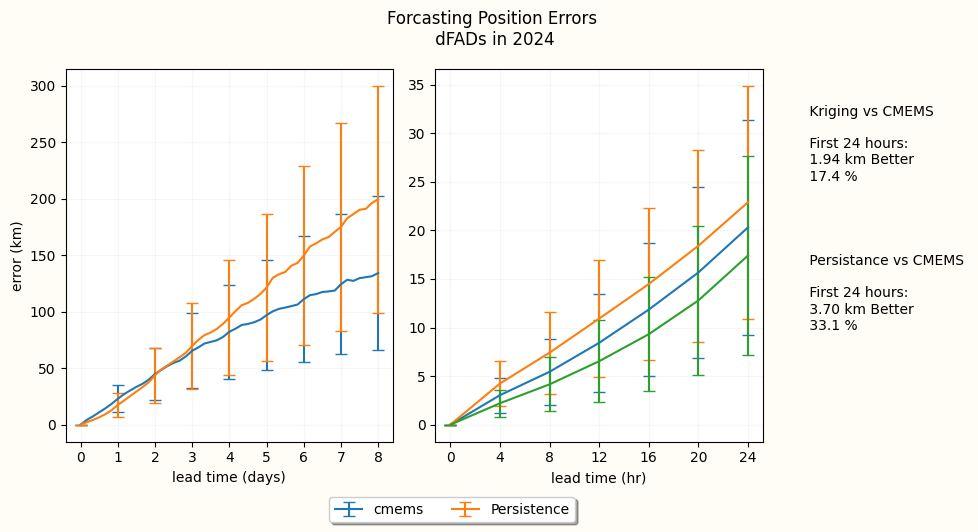

In [13]:
fig = plt.figure(figsize=(10,5))
gs = gridspec.GridSpec(1, 3, width_ratios=[3,3,1])

ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1])
ax_stats = fig.add_subplot(gs[0,2])
ax_stats.axis("off")

stats_k = f" Kriging vs CMEMS \n \n First 24 hours: \n {kriging_km24:0.2f} km Better \n{krigging_percent24: 0.1f} %"
ax_stats.text(0,0.7,stats_k)
stats_p = f" Persistance vs CMEMS \n \n First 24 hours: \n {Pers_km24:0.2f} km Better \n{Pers_percent24: 0.1f} %"
ax_stats.text(0,0.3,stats_p)

#ax0.errorbar(bins[:]/24, lte[:], yerr = std, errorevery=6, capsize = 4, label = "kriging")
ax0.errorbar(bins[:]/24, lte2[:], yerr = std2[:], errorevery=6, capsize = 4, label = "cmems")
ax0.errorbar(bins[:]/24, lte3[:], yerr = std3[:], errorevery = 6, capsize = 4, label = "Persistence")


ax1.errorbar(bins[0:7], lte[:7], yerr = std[:7], capsize = 4)
ax1.errorbar(bins[0:7], lte2[:7], yerr = std2[:7], capsize = 4)
ax1.errorbar(bins[0:7], lte3[:7], yerr = std3[:7], capsize =4 )
ax0.set_xticks(np.linspace(0,8,9))
ax1.set_xticks(np.linspace(0,24,7))

ax0.set_ylabel("error (km)")
ax0.set_xlabel("lead time (days)")
ax1.set_xlabel("lead time (hr)")
ax0.grid(alpha = 0.1)
ax1.grid(alpha = 0.1)


fig.legend(loc='upper center', bbox_to_anchor=(3.2/7, 0.02),
          fancybox=True, shadow=True, ncol=5)
fig.suptitle("Forcasting Position Errors \n dFADs in 2024 ")
fig.set_facecolor("#FFFDF6")
fig.tight_layout()
fig.savefig(r"C:\FATE\Figures\Leadtime_drifter_vs_cmems.png")

### Corrilation between errors

dict_keys([Interval(0.0, 4.0, closed='right'), Interval(4.0, 8.0, closed='right'), Interval(8.0, 12.0, closed='right'), Interval(12.0, 16.0, closed='right'), Interval(16.0, 20.0, closed='right'), Interval(20.0, 24.0, closed='right'), Interval(24.0, 28.0, closed='right'), Interval(28.0, 32.0, closed='right'), Interval(32.0, 36.0, closed='right'), Interval(36.0, 40.0, closed='right'), Interval(40.0, 44.0, closed='right'), Interval(44.0, 48.0, closed='right'), Interval(48.0, 52.0, closed='right'), Interval(52.0, 56.0, closed='right'), Interval(56.0, 60.0, closed='right'), Interval(60.0, 64.0, closed='right'), Interval(64.0, 68.0, closed='right'), Interval(68.0, 72.0, closed='right'), Interval(72.0, 76.0, closed='right'), Interval(76.0, 80.0, closed='right'), Interval(80.0, 84.0, closed='right'), Interval(84.0, 88.0, closed='right'), Interval(88.0, 92.0, closed='right'), Interval(92.0, 96.0, closed='right'), Interval(96.0, 100.0, closed='right'), Interval(100.0, 104.0, closed='right'), Int

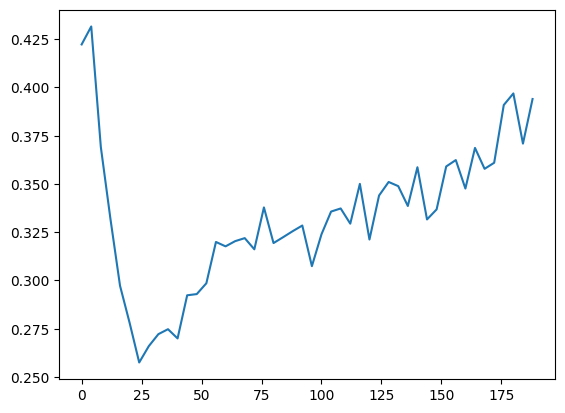

In [14]:
corrs = {}

for b in ds["lead_bins"].cat.categories:   # iterate over all bins
    e1 = ds.loc[ds["lead_bins"] == b, "error_km"]
    e2 = ds2.loc[ds2["lead_bins"] == b, "error_km"]

    # align lengths (optional — depends on your data structure)
    n = min(len(e1), len(e2))
    e1 = e1.iloc[:n]
    e2 = e2.iloc[:n]

    if n > 1:   # need at least 2 samples to compute correlation
        corr = np.corrcoef(e1, e2)[0, 1]
    else:
        corr = np.nan

    corrs[b] = corr

fig, ax = plt.subplots()
ax.plot(bins[0:-1], corrs.values()) 
print(corrs.keys())
print(bins)
print(corrs.values())
## think this is saying both models get errors the same after 4 hours, then theyre errors are uncorrilated. krigging gets it right or cmems? 

In [15]:
### Plotting indivigual trajectories. 

def add_initial_time(ds): 
        
    ds["leadtime_td"] = pd.to_timedelta( ds["leadtime"], "hours")
    ds["Time"] = pd.to_datetime(ds["Time"])
    ds["initial_time"] = ds["Time"] - ds["leadtime_td"]
    ds["initial_time"] = ds["initial_time"].dt.round("h")
    return ds

ds = add_initial_time(ds)
ds1 = add_initial_time(ds2)
ds3 = add_initial_time(ds3)

## Plotting indivigual tracks

In [16]:
def drifter_forecast_plot(individual_csv, true_data,   datetime_column='DateTime'):
    df = individual_csv
    commid = df['BuoyID'].unique()
    df = df.rename(columns = {"Time": "DateTime"})
    true_data = true_data.rename(columns = {"Time": "DateTime"})
    df=df.sort_values('DateTime')
    true_data=true_data.sort_values('DateTime')
    #true_data = pd.read_csv(f'../individual_commID_data/cleaned_data_inconsistent_removed/new/cleaned_new_approach{commid}.csv')
 
    # Palmyra Atoll GPS coordinates
    pa_lat = 5.8900
    pa_lon = 197.9200- 360# adjusted by adding 360
 
    df.loc[:, datetime_column] = pd.to_datetime(df[datetime_column])
    true_data.loc[:, datetime_column] = pd.to_datetime(true_data[datetime_column])
    # Filter by week
    start_date = df[datetime_column].min()
    end_date = df[datetime_column].max()
 
    # Only get time of forecast
    timed_data = true_data[(true_data['DateTime'] >= start_date) & (true_data['DateTime']<=end_date)]
 
    #first_week_data = df[(df[datetime_column] >= start_date) & (df[datetime_column]<end_date)]
    timed_data  = timed_data.sort_values("DateTime")

 
    plt.figure(figsize=(20,10))
    plt.plot(pa_lon, pa_lat, 'ro', markersize=8, label='Palmyra Atoll')
    plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center right')
 
 
    plt.scatter(
        df['lon_forcast'],
        df['lat_forcast'],
        # hue=datetime_column,
        # palette='viridis',
        label='Forecasted Trajectory'
    )
    plt.plot(
        timed_data['lon_true'],
        timed_data['lat_true'],
        color='black',
        label='True Trajectory'
    )
    
    plt.annotate(
        f'Start Date: {start_date}',
        xy=(0.02, 0.98),
        xycoords='axes fraction',
        ha='left',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round, pad=0.2', fc='white', ec='black', lw=1, alpha=0.7)
    )
 
    plt.annotate(
        f'End Date: {end_date}',
        xy=(0.98, 0.98),
        xycoords='axes fraction',
        ha='right',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round, pad=0.2', fc='white', ec='black', lw=1, alpha=0.7)
    )
    
 
    plt.title(f'Scatter Plot of Latitude vs. Longitude of CommId: {commid} Forecast vs True')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    #plt.savefig(f'../forecast_plots/comparison_plots/comparison_commID_{commid}_forecast_vs_true.png')

In [31]:
dFADs = gpd.read_parquet(r"..\Data\Mapped_SAT_MI_Cleanedspeeds.parquet") 
def True_dFAD_data( ds, buoyID):
    Truedata = dFADs.query("BuoyName == @buoyID").reset_index(drop = True)
    x,y= Truedata.at[0,"geometry"].xy
    time = Truedata.at[0,"TimeStamp"]
    Truedata = pd.DataFrame({"DateTime":time, "lat_true": y, "lon_true": x})
    Truedata.DateTime = pd.to_datetime(Truedata.DateTime)
    return Truedata

def Add_bathymetry(fig,ax):
    from matplotlib import cm
    bath = xr.open_dataset(r"..\Data\bath.nc")
    bath_cmap = cm.get_cmap("Blues_r").copy()
    bath_cmap.set_over('green')
    negative_levels = np.linspace(-10000, 0, 11)
    cbr = ax.contourf( bath["lon"], bath["lat"], bath["elevation"], 
                    linestyle = "-", cmap = bath_cmap, alpha = 0.8, levels = negative_levels, extend = "max")
    fig.colorbar(cbr)
    cbr.set_label("m/s")
    return fig, ax

def plot_collectionzone(ax): 
    import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def plot_circle_km(ax, radius_km=5, **patch_kwargs):
    from matplotlib.patches import Circle
    point = Palmyra_obj()
    circle = Circle(
        (point.x, point.y),
        radius_km,
        fill=False, 
        alpha = 0.75,
        **patch_kwargs
    )
    ax.add_patch(circle)
    return ax

def set_palmyra_lims(ax):
    ax.set_xlim(-163.6, -160.7)
    ax.set_ylim(4.5,7.7)
    return ax

788


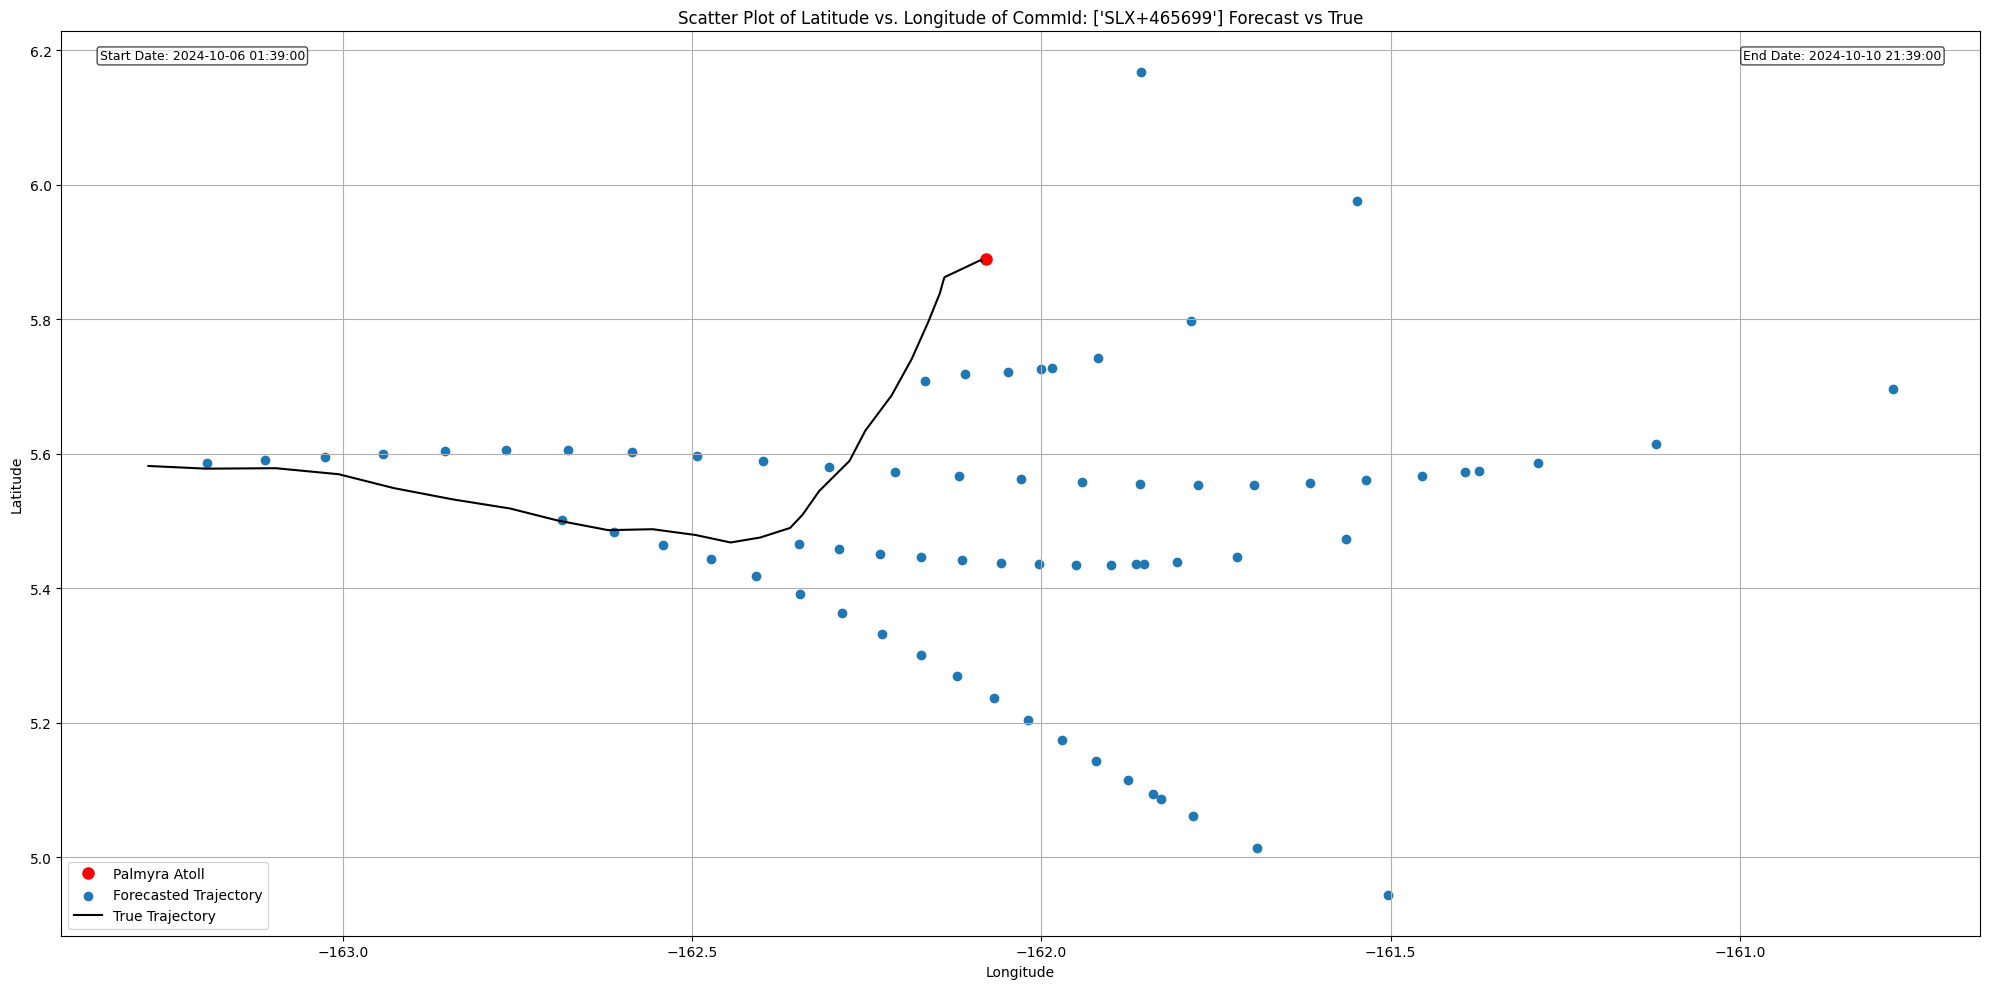

In [18]:
IDs = ds.BuoyID.unique()
print(len(IDs))
buoyID ="SLX+465699"

Truedata = True_dFAD_data(dFADs, buoyID)

perplot = ds.query("BuoyID == @buoyID ") ##SLX+487116 #10 had loops ##16 weird points ##119 ##hit palyra SLX+463917
#truedata = perplot.query("leadtime == 0 ")
drifter_forecast_plot(perplot, true_data=Truedata, datetime_column="DateTime")

C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_17424\3066238171.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bath_cmap = cm.get_cmap("Blues_r").copy()
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_17424\3066238171.py:16: UserWarning: The following kwargs were not used by contour: 'linestyle'
  cbr = ax.contourf( bath["lon"], bath["lat"], bath["elevation"],


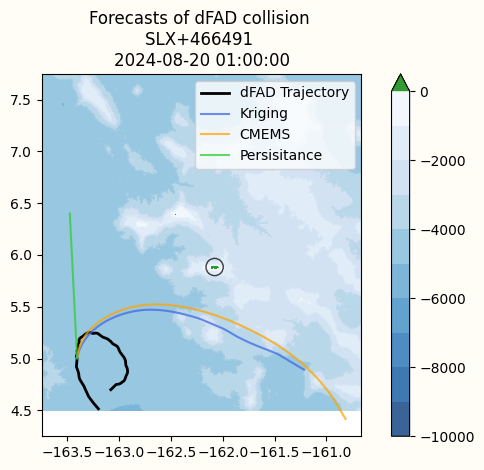

In [33]:
##plotting one track 
### Give it one dFAD, one point, and all three forcasts 
def plot_Forcasts(BuoyID:str, truedata, dsforcast: list,startday: int, labels: list, fig, ax, forcastlength = pd.Timedelta(days= 8), pastTrajectory = pd.Timedelta(days = 3)): ## could add getting startime and just get nearest point from that.
    ## getting true data
    perplot = dsforcast[0].query("BuoyID == @BuoyID ") ##SLX+487116 #10 had loops ##16 weird points ##119 ##hit palyra SLX+463917
    forcasttimes = perplot.query("leadtime == 0 ").reset_index(drop= True)
    starttime = forcasttimes.at[startday, "Time"]
    starttime = pd.to_datetime(starttime)
    starttime = starttime.round('h')
    truedata = truedata[truedata.DateTime < (starttime + forcastlength)]
    truedata = truedata[truedata.DateTime > (starttime - pastTrajectory)]
    ##set x and y lims 
    #fig, ax = plt.subplots(figsize = (6,6))
    ax.plot(truedata.lon_true, truedata.lat_true, label = "dFAD Trajectory", lw= 2, color = "k")
    colors = ["royalblue", "orange","limegreen"]
    ##Get forcast from that starttime 
    for i,ds in enumerate(dsforcast):
        ds = ds.query(f"BuoyID == @BuoyID")
        ds = ds.query(f"initial_time == @starttime").reset_index(drop = True)
        starty =  ds.at[0,"lat_true"]
        startx =  ds.at[0,"lon_true"]
        ax.plot(ds.lon_forcast, ds.lat_forcast, label= labels[i], alpha = 0.75, color = colors[i] )
    deg = 0.5
    #ax.set_ylim([starty -deg, starty +deg+0.2])
    #ax.set_xlim([startx -deg, startx+deg])
    ax.plot(startx, starty, color = "k", lw = 10, alpha= 1)
    ax.set_title(f"Forecasts of dFAD collision \n{BuoyID} \n{starttime}")
    return fig, ax
buoyID  = 'SLX+466491'
Truedata = True_dFAD_data(dFADs, buoyID)
fig, ax = plt.subplots()
fig, ax = plot_Forcasts("SLX+466491", Truedata, [ds,ds2,ds3], startday = 1, labels = ["Kriging", "CMEMS", "Persisitance"], fig= fig, ax = ax, pastTrajectory = pd.Timedelta(days = 7)) 
ax.legend()  
#ax = Palmyra_plot(ax)
fig, ax = Add_bathymetry(fig, ax)
ax.set_aspect("equal")
ax = plot_circle_km(ax, radius_km= 0.0833)
#fig.savefig("Forecasts_SLX+463917_3.png")
fig.set_facecolor("#FFFDF6")
fig.tight_layout()


C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_17424\3066238171.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bath_cmap = cm.get_cmap("Blues_r").copy()
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_17424\3066238171.py:16: UserWarning: The following kwargs were not used by contour: 'linestyle'
  cbr = ax.contourf( bath["lon"], bath["lat"], bath["elevation"],


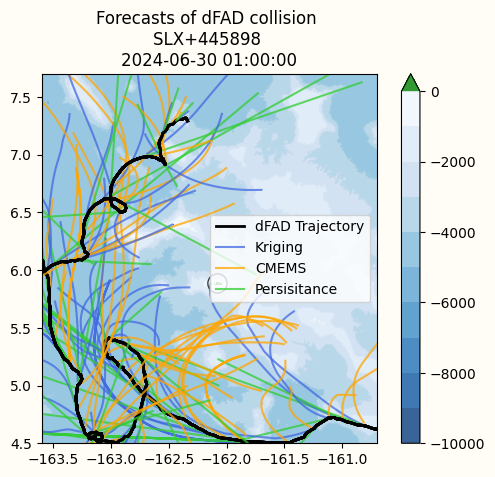

In [46]:
buoyID = "SLX+445898"
Truedata = True_dFAD_data(dFADs, buoyID)
fig, ax = plt.subplots()
for i in range(58):
    fig, ax = plot_Forcasts(buoyID, Truedata, [ds,ds2,ds3], startday = i,
                            labels = ["Kriging", "CMEMS", "Persisitance"], fig= fig, ax = ax,
                            pastTrajectory = pd.Timedelta(days = 7)) 

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
fig, ax = Add_bathymetry(fig, ax)
ax.set_aspect("equal")
ax = plot_circle_km(ax, radius_km= 0.0833)
ax = set_palmyra_lims(ax)
fig.set_facecolor("#FFFDF6")


In [40]:
dFADs = distance_from_Palymra(dFADs)
dFADs = dFADs.sort_values("distance_km")
dFADs2024 = dFADs[dFADs["MinOfDate"] > pd.to_datetime("2024-1-1")]
dFADs2024 = dFADs2024[dFADs2024["MinOfDate"] < pd.to_datetime("2025-1-1")]
dFADs2024 = dFADs2024.reset_index(drop = True)
ngps = len(Column_to_List(dFADs2024,"TimeStamp"))
print(ngps)

dFADs_5km = dFADs[dFADs.distance_km < 11.12] ##6 nautical miles
print(len(dFADs_5km))
print(dFADs.MinOfDate.min(), dFADs.MaxOfDate.max())
(ngps*(1/111**2)*4/24/365)*24*24
print(len(dFADs))
print(dFADs.query("BuoyName == 'SLX+480197'"))

49761
160
2021-06-28 11:12:00 2025-09-24 21:48:00
2898
      index    BuoyName           MinOfDate           MaxOfDate  \
2477   2654  SLX+480197 2025-01-14 13:23:00 2025-02-18 09:23:00   

                                              TimeStamp  \
2477  [2025-01-14 14:04:00, 2025-01-14 17:23:00, 202...   

                                               geometry  \
2477  LINESTRING (-160.68282 4.89652, -160.73957 4.8...   

                                                  x_deg  \
2477  [-0.013669999999990523, -0.05674999999999386, ...   

                                                  y_deg  \
2477  [-0.006429999999999936, -0.0237999999999996, -...   

                                                   x_km  \
2477  [-1.5200346472290938, -6.310312087078173, -7.5...   

                                                   y_km  ...  \
2477  [-0.6746746563870138, -2.4974494995747727, -2....  ...   

                                               xy_speed points_removed  \
2477  [0.676

Text(0.5, 1.0, 'number of new dFADs')

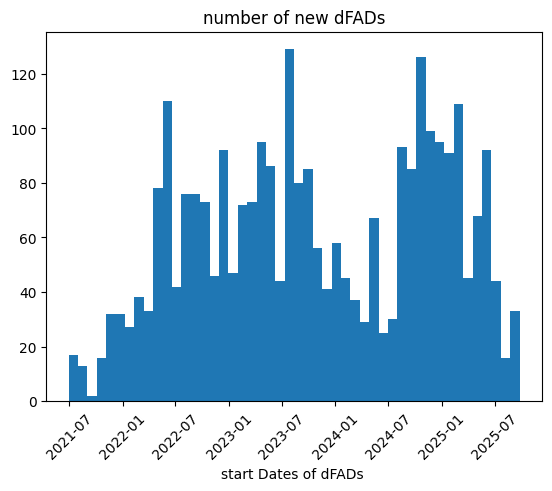

In [22]:
fig, ax = plt.subplots()
ax.hist(dFADs['MaxOfDate'], bins = 4*12)
ax.tick_params(axis='x', labelrotation=45)
ax.set_xlabel("start Dates of dFADs ")
ax.set_title("number of new dFADs")